# Triagem e duplicatas

Veremos algumas estratégias para lidar com a triagem de informações e a identificação de duplicatas em conjuntos de imagens. A triagem é um processo essencial para garantir que apenas os dados relevantes sejam mantidos, enquanto a identificação de duplicatas ajuda a evitar redundâncias e vazamento de informações.

In [1]:
import hashlib
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Diretório contendo as imagens
images_dir = Path("../dados/pvd_images/images")

## Listagem dos arquivos

In [2]:
# Todos os arquivos no diretório
print(f"total: {len(list(images_dir.iterdir()))} arquivos")
# Todos os arquivos .jpeg
print(f"jpeg: {len(list(images_dir.glob('*.jpeg')))} arquivos")
# Todos os arquivos .jpg
print(f"jpg: {len(list(images_dir.glob('*.jpg')))} arquivos")

total: 1845 arquivos
jpeg: 1487 arquivos
jpg: 109 arquivos


A forma correta é listar tudo e filtrar pelo sufixo **em minúsculas**, contra um conjunto de
extensões conhecidas.

In [3]:
EXTENSIONS = [".jpeg", ".jpg", ".png", ".webp", ".bmp", ".tif", ".tiff"]

def is_image_file(path):
    """Verifica se o caminho é de um arquivo de imagem válido."""
    return path.is_file() and path.suffix.lower() in EXTENSIONS

def get_images(directory):
    """Retorna uma lista de caminhos de arquivos de imagem no diretório."""
    return [path for path in directory.iterdir() if is_image_file(path)]

image_paths = get_images(images_dir)

print(f"{len(image_paths)} arquivos de imagem")

1845 arquivos de imagem


## Montar o inventário

Iremos criar uma tabela com as informações de cada arquivo.

Dois cuidados que fazem diferença num conjunto grande:

- `Image.open` lê apenas o cabeçalho, então esse laço é rápido mesmo com milhares de arquivos;
- o `try` registra o erro numa coluna em vez de interromper. Sem ele, um único arquivo
  quebrado derruba o laço depois de vários minutos de trabalho já feito.

In [4]:
def build_inventory(image_paths):
    """Constrói um inventário de imagens, com informações sobre cada arquivo."""

    rows = []
    for path in image_paths:
        record = {
            "image_name": path.name, 
            "suffix": path.suffix,
            "size_kb": path.stat().st_size / 1024,
            "error": ""
            }
        try:
            with Image.open(path) as image:
                record.update({
                    "format": image.format, 
                    "mode": image.mode,
                    "width": image.width, 
                    "height": image.height
                    })
        except Exception as error:
            record["error"] = str(error)
        rows.append(record)

    inventory = pd.DataFrame(rows)
    inventory["aspect_ratio"] = inventory["width"] / inventory["height"]

    return inventory

inventory = build_inventory(image_paths)
inventory.head()

,image_name,suffix,size_kb,error,format,mode,width,height,aspect_ratio
0,kjnaw.jpeg,.jpeg,132.937500,,JPEG,RGB,500,375,1.333333
1,nb4gh.JPEG,.JPEG,60.360352,,JPEG,RGB,333,500,0.666000
2,orwix.jpeg,.jpeg,167.545898,,JPEG,RGB,375,500,0.750000
3,zz0jd.jpeg,.jpeg,115.625000,,JPEG,L,500,494,1.012146
4,z5tv6.jpeg,.jpeg,29.735352,,JPEG,RGB,400,300,1.333333


In [5]:
print(f"{(inventory['error'] != '').sum()} erros de leitura")

0 erros de leitura


## Análise do inventário

A análise do inventário é similar à análise que fizemos com tabelas.

In [6]:
print("Extensões:")
print(inventory["suffix"].value_counts())
print("\nFormatos de verdade:")
print(inventory["format"].value_counts())
print("\nModos de cor:")
print(inventory["mode"].value_counts())

Extensões:
suffix
.jpeg    1487
.jpg      109
.JPEG     105
.JPG       99
.png       45
Name: count, dtype: int64

Formatos de verdade:
format
JPEG    1800
PNG       45
Name: count, dtype: int64

Modos de cor:
mode
RGB     1731
L         75
RGBA      22
P         10
CMYK       4
1          3
Name: count, dtype: int64


## A leitura robusta

Faremos uma função de leitura robusta. Ela resolve três
problemas:

1. aplica a rotação que estiver gravada no EXIF, senão parte das fotos fica deitada;
2. compõe o canal alfa sobre um fundo branco, em vez de descartá-lo em silêncio;
3. converte para `RGB`, o que resolve paleta, CMYK, cinza e 1 bit de uma vez só.

Repare que o item 2 é uma **decisão**, e não a resposta certa. Compor sobre preto daria outros
pixels. 

In [7]:
from PIL import ImageOps

def load_rgb(path):
    """Abre qualquer imagem do conjunto e devolve um RGB de 8 bits."""
    with Image.open(path) as image:
        image = ImageOps.exif_transpose(image)
        if image.mode in ("RGBA", "LA") or "transparency" in image.info:
            image = image.convert("RGBA")
            background = Image.new("RGBA", image.size, (255, 255, 255, 255))
            image = Image.alpha_composite(background, image)
        return image.convert("RGB")

## A forma das imagens

Com o inventário pronto, podemos plotar a distribuição de resolução e de proporção.

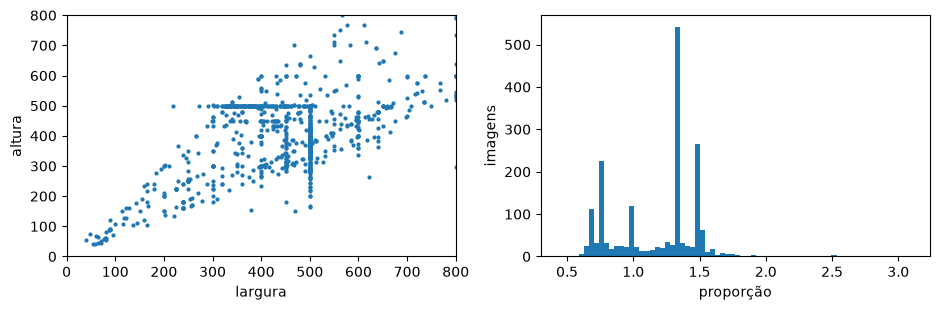

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))

axes[0].scatter(inventory["width"], inventory["height"], s=4)
axes[0].set_xlim(0, 800)
axes[0].set_ylim(0, 800)
axes[0].set_xlabel("largura")
axes[0].set_ylabel("altura")

axes[1].hist(inventory["aspect_ratio"], bins=70)
axes[1].set_xlabel("proporção")
axes[1].set_ylabel("imagens")

fig.tight_layout()
plt.show()

## Duplicatas exatas

In [9]:
def get_md5(image_paths):
    """Calcula o hash MD5 de cada arquivo de imagem no diretório."""
    hashes = []
    for path in image_paths:
        md5_hash = hashlib.md5(path.read_bytes()).hexdigest()
        hashes.append(md5_hash)
    return np.array(hashes)

inventory["md5"] = get_md5(image_paths)
# Agrupa os arquivos pelo hash MD5 e filtra apenas os grupos com mais de um arquivo
md5_groups = inventory.groupby("md5").filter(lambda grupo: len(grupo) > 1)

print(f"{md5_groups['md5'].nunique()} grupos de arquivos idênticos")
print(f"{len(md5_groups)} arquivos")

17 grupos de arquivos idênticos
35 arquivos


In [10]:
md5_groups.sort_values("md5")[["image_name", "md5"]].head(8)

,image_name,md5
548,8gvzi.jpeg,13c14fca85f9b4e2c5136bd176b98ddb
1241,k1j6f.jpeg,13c14fca85f9b4e2c5136bd176b98ddb
297,u82pi.jpeg,40c118c8f4678361349f58756da1adf6
301,svz2e.jpeg,40c118c8f4678361349f58756da1adf6
386,hju1g.jpeg,5602fa784a28ac50edbf5ca188ce01ae
742,yeawh.jpeg,5602fa784a28ac50edbf5ca188ce01ae
1509,f7593.jpeg,76fda1ad32dddb65ec016641d28af9cb
1750,ii2jp.jpeg,76fda1ad32dddb65ec016641d28af9cb


## Quase-duplicatas

O `md5` só acha cópia de arquivo. Para achar cópia de **conteúdo** precisamos de um hash que
mude pouco quando a imagem muda pouco.

A biblioteca `cv2` (OpenCV) possui vários algoritmos de hash. Vamos usar o `pHash`, que devolve 8 bytes, ou seja 64 bits.

In [11]:
def phash(path):
    """pHash de um arquivo."""
    array = np.asarray(load_rgb(path))
    # O OpenCV espera imagens no formato BGR, então precisamos converter de RGB para BGR antes de calcular o pHash.
    array = cv2.cvtColor(array, cv2.COLOR_RGB2BGR)
    return cv2.img_hash.pHash(array)[0]

reference = "mnz1u.jpg"
example = phash(images_dir / reference)
print(f"bytes ...... {example}")
print(f"bits ....... {np.unpackbits(example)}")

bytes ...... [ 62 197  69  49 142   0  57 155]
bits ....... [0 0 1 1 1 1 1 0 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 1 0 0 1 1 0 0 0 1 1 0 0 0 1
 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 1 1 0 0 1 1 0 1 1]


A comparação entre dois hashes é a **distância de Hamming**, que conta em quantos bits eles
diferem. Como cada hash tem 64 bits, a distância vai de 0 a 64.

In [12]:
def hamming(first, second):
    """Em quantos bits os dois hashes diferem."""
    return int((np.unpackbits(first) != np.unpackbits(second)).sum())

comparisons = ["o6c33.jpeg", "26yfp.jpeg"]

for name in comparisons:
    print(f"{name} ... distância {hamming(phash(images_dir / reference), phash(images_dir / name))}")

o6c33.jpeg ... distância 5
26yfp.jpeg ... distância 37


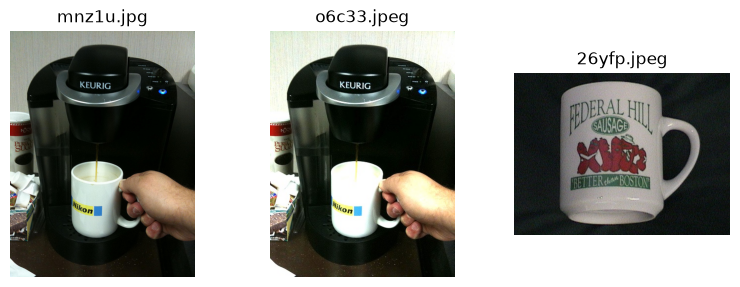

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(9.5, 3.2))

for name, ax in zip([reference] + comparisons, axs):
    ax.imshow(load_rgb(images_dir / name))
    ax.set_title(name)
    ax.axis("off")


Dois arquivos com distância pequena são quase-duplicatas. A distância para uma imagem completamente distinta é bem maior.

In [14]:
hashes = np.array([phash(path) for path in image_paths])
bits = np.unpackbits(hashes, axis=1)
bits.shape

(1845, 64)

Comparar todos os pares seria caro: são $(1845 \times 1844) / 2$ pares, ou seja quase 1,7 milhão de
comparações, e isso cresce com o quadrado do tamanho do conjunto.

A busca por vizinhos do `sklearn` resolve o mesmo problema sem enumerar todos os pares.

In [15]:
from sklearn.neighbors import NearestNeighbors

def find_duplicates(bits, threshold_bits=10):
    """Encontra imagens quase-duplicatas com base em seus hashes de bits. threshold_bits é o número máximo 
    de bits diferentes para considerar duas imagens quase-duplicatas."""
    n_bits = bits.shape[1]
    # O limiar de distância em fração de bits
    threshold = threshold_bits / n_bits

    searcher = NearestNeighbors(metric="hamming").fit(bits)
    # Para cada item, radius_neighbors devolve uma lista de vizinhos dentro do raio, incluindo o próprio item. 
    distances, indices = searcher.radius_neighbors(bits, radius=threshold)

    duplicates = {}
    for ref_idx, neighbors in enumerate(indices):
        if len(neighbors) > 1:
            # Remove o próprio índice da lista de vizinhos
            neighbors = set(neighbors.tolist()) - {ref_idx}
            duplicates[ref_idx] = neighbors

    return duplicates

duplicates = find_duplicates(bits, threshold_bits=10)

count = 0
for neighbors in duplicates.values():
    count += len(neighbors)

print(duplicates)        
print(f"Total de imagens com duplicatas: {count//2}")

{16: {373}, 20: {192, 1641}, 25: {1074}, 29: {570}, 32: {146}, 61: {862}, 73: {645, 406}, 79: {1377}, 98: {258}, 103: {760, 914}, 104: {560}, 105: {296}, 108: {216}, 112: {1357}, 115: {1293}, 117: {1131}, 142: {180}, 146: {32}, 180: {142}, 184: {193}, 192: {1641, 20}, 193: {184}, 197: {1720}, 211: {1675, 821, 1206}, 216: {108}, 234: {635, 710, 1787}, 244: {931}, 247: {1757}, 255: {1090}, 258: {98}, 272: {1124}, 291: {578}, 296: {105}, 297: {301}, 298: {1463}, 301: {297}, 314: {1842}, 321: {1581}, 329: {1155}, 336: {624}, 337: {1540}, 373: {16}, 386: {742}, 388: {456, 402, 1701}, 400: {1837}, 402: {456, 388, 1701}, 406: {73, 645}, 410: {1153}, 411: {896}, 417: {1083}, 423: {591}, 452: {498}, 456: {402, 388, 1701}, 495: {658, 603}, 498: {452}, 514: {748}, 515: {1198}, 518: {664}, 525: {1528, 1070}, 531: {1411}, 548: {1241}, 560: {104}, 570: {29}, 578: {291}, 589: {884}, 590: {1683}, 591: {423}, 599: {630}, 603: {658, 495}, 613: {726}, 623: {743}, 624: {336}, 630: {599}, 632: {1735}, 634: